In [2]:
import yfinance as yf
import pandas as pd

# 삼성전자 종목코드: 005930.KS (한국 코스피)
df = yf.download("005930.KS", start="2023-01-01", end="2024-12-31")

# 데이터 개수 확인 (100개 이상인지!)
print("데이터 개수:", len(df))
print(df.head())   # 앞부분 5줄 미리보기

[*********************100%***********************]  1 of 1 completed

데이터 개수: 489
Price              Close          High           Low          Open    Volume
Ticker         005930.KS     005930.KS     005930.KS     005930.KS 005930.KS
Date                                                                        
2023-01-02  51925.335938  52486.690921  51644.658446  51925.335938  10031448
2023-01-03  51831.785156  52393.140230  50989.752545  51831.785156  13547030
2023-01-04  54077.203125  54264.321475  52018.901276  52112.460451  20188071
2023-01-05  54451.433594  55012.788579  53890.078608  54451.433594  15682826
2023-01-06  55199.906250  55574.142903  54170.755456  54544.992108  17334989


In [5]:
df.to_csv("data/samsung_2023_2024.csv")
print("저장 완료!")

저장 완료!


In [6]:
print(df.columns)   # 어떤 컬럼이 있는지
print(df.info())    # 데이터 타입, 결측치 정보

MultiIndex([( 'Close', '005930.KS'),
            (  'High', '005930.KS'),
            (   'Low', '005930.KS'),
            (  'Open', '005930.KS'),
            ('Volume', '005930.KS')],
           names=['Price', 'Ticker'])
<class 'pandas.DataFrame'>
DatetimeIndex: 489 entries, 2023-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   (Close, 005930.KS)   489 non-null    float64
 1   (High, 005930.KS)    489 non-null    float64
 2   (Low, 005930.KS)     489 non-null    float64
 3   (Open, 005930.KS)    489 non-null    float64
 4   (Volume, 005930.KS)  489 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 22.9 KB
None


In [7]:
# 각 컬럼에 비어있는 값이 몇 개인지 확인
print(df.isnull().sum())

Price   Ticker   
Close   005930.KS    0
High    005930.KS    0
Low     005930.KS    0
Open    005930.KS    0
Volume  005930.KS    0
dtype: int64


In [8]:
# 방법 1: 빈 값이 있는 행 제거
df = df.dropna()

# 방법 2: 앞의 값으로 채우기 (주가엔 이 방법이 자연스러움)
# df = df.fillna(method='ffill')

In [9]:
print(df.index)  

DatetimeIndex(['2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05',
               '2023-01-06', '2023-01-09', '2023-01-10', '2023-01-11',
               '2023-01-12', '2023-01-13',
               ...
               '2024-12-16', '2024-12-17', '2024-12-18', '2024-12-19',
               '2024-12-20', '2024-12-23', '2024-12-24', '2024-12-26',
               '2024-12-27', '2024-12-30'],
              dtype='datetime64[s]', name='Date', length=489, freq=None)


In [10]:
# 종가의 기초 통계 확인
print(df['Close'].describe())

Ticker     005930.KS
count     489.000000
mean    66248.467344
std      7891.696105
min     48362.078125
25%     59604.558594
50%     66830.742188
75%     71349.859375
max     84619.195312


In [11]:
print(df.isnull().sum())      # 결측치 개수
print(df['Close'].describe()) # 종가 통계

Price   Ticker   
Close   005930.KS    0
High    005930.KS    0
Low     005930.KS    0
Open    005930.KS    0
Volume  005930.KS    0
dtype: int64
Ticker     005930.KS
count     489.000000
mean    66248.467344
std      7891.696105
min     48362.078125
25%     59604.558594
50%     66830.742188
75%     71349.859375
max     84619.195312


In [12]:
# 컬럼을 1층으로 평탄화 (종목이 하나일 때)
df.columns = df.columns.get_level_values(0)
print(df.columns)   # Close, High, Low, Open, Volume 로 깔끔해짐

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [13]:
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [14]:
# 20일, 60일 이동평균 계산
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA60'] = df['Close'].rolling(window=60).mean()

print(df[['Close', 'MA20', 'MA60']].tail())  # 마지막 5줄 확인

Price              Close          MA20          MA60
Date                                                
2024-12-23  51851.121094  52825.146289  55103.349544
2024-12-24  52723.386719  52636.156445  54942.804948
2024-12-26  51948.031250  52505.316992  54771.583073
2024-12-27  52399.832031  52435.834570  54651.504297
2024-12-30  51911.937500  52404.953906  54526.524479


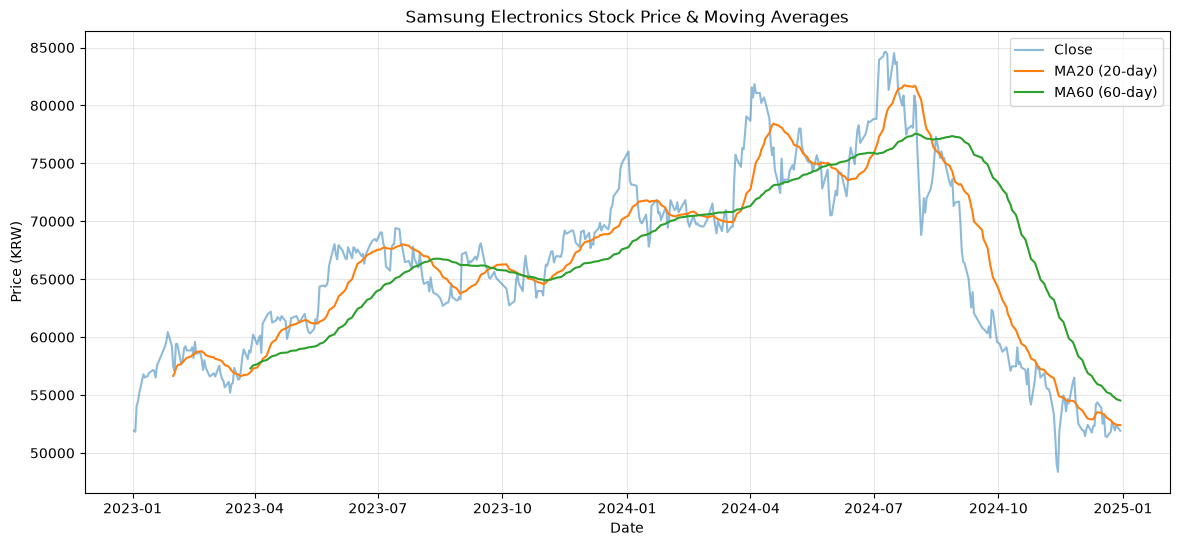

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Close', alpha=0.5)
plt.plot(df.index, df['MA20'], label='MA20 (20-day)')
plt.plot(df.index, df['MA60'], label='MA60 (60-day)')
plt.title('Samsung Electronics Stock Price & Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (KRW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('images/ma_trend.png')  # 리포트용 이미지 저장
plt.show()

In [17]:
# 전날 대비 변화율(%) 계산
df['Return'] = df['Close'].pct_change() * 100

print(df['Return'].describe())  # 수익률 통계

count    488.000000
mean       0.014605
std        1.713726
min      -10.301496
25%       -0.984196
50%        0.000000
75%        0.835085
max        7.214419
Name: Return, dtype: float64


In [18]:
# 가장 많이 오른 날 TOP 5
print("📈 급등 TOP 5")
print(df['Return'].nlargest(5))

# 가장 많이 떨어진 날 TOP 5
print("\n📉 급락 TOP 5")
print(df['Return'].nsmallest(5))

📈 급등 TOP 5
Date
2024-11-15    7.214419
2023-09-01    6.128540
2024-11-18    5.981308
2024-03-20    5.631858
2024-05-07    4.768011
Name: Return, dtype: float64

📉 급락 TOP 5
Date
2024-08-05   -10.301496
2024-11-13    -4.528294
2024-10-24    -4.230125
2024-08-02    -4.211794
2024-09-30    -4.205607
Name: Return, dtype: float64


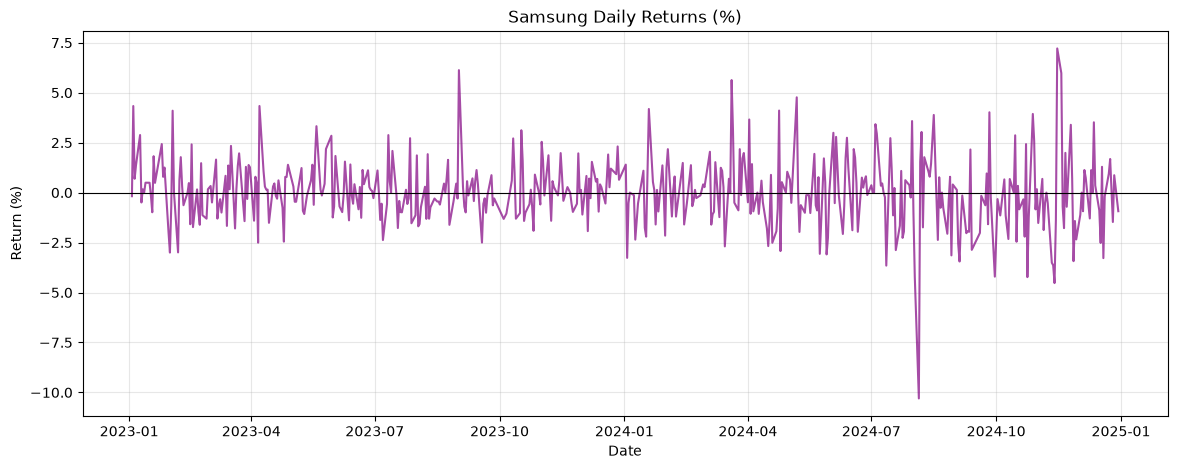

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Return'], color='purple', alpha=0.7)
plt.axhline(y=0, color='black', linewidth=0.8)  # 0% 기준선
plt.title('Samsung Daily Returns (%)')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.grid(True, alpha=0.3)
plt.savefig('images/daily_return.png')
plt.show()

In [22]:
# 월별로 묶어서 종가 평균 계산
monthly_avg = df['Close'].resample('ME').mean()
print(monthly_avg)

Date
2023-01-31    56650.076953
2023-02-28    58278.008203
2023-03-31    57238.505682
2023-04-30    61029.178906
2023-05-31    62953.546094
2023-06-30    67480.315848
2023-07-31    67473.844122
2023-08-31    64011.374822
2023-09-30    66394.327303
2023-10-31    64559.193257
2023-11-30    67885.102450
2023-12-31    70205.105674
2024-01-31    71115.419744
2024-02-29    70389.688322
2024-03-31    72397.747266
2024-04-30    77330.545387
2024-05-31    74629.345703
2024-06-30    75675.060855
2024-07-31    81325.613111
2024-08-31    73728.570312
2024-09-30    63678.855035
2024-10-31    57394.830078
2024-11-30    54047.929315
2024-12-31    52404.953906
Freq: ME, Name: Close, dtype: float64


In [23]:
# 월(1~12)별로 수익률 평균 → 반복 패턴 확인
df['Month'] = df.index.month
monthly_return = df.groupby('Month')['Return'].mean()
print(monthly_return)

Month
1     0.073120
2    -0.000207
3     0.443035
4    -0.079447
5     0.095400
6     0.318210
7     0.002497
8    -0.356099
9    -0.403323
10   -0.139993
11    0.015182
12    0.183973
Name: Return, dtype: float64


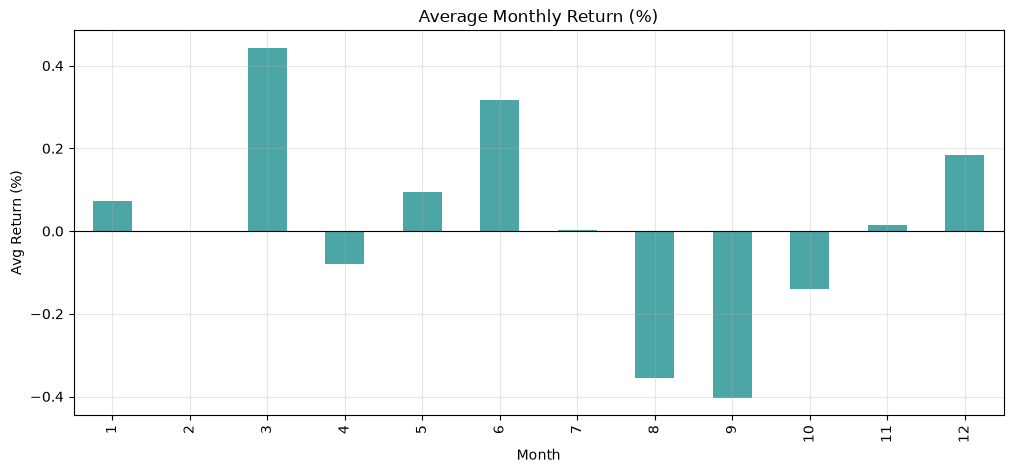

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
monthly_return.plot(kind='bar', color='teal', alpha=0.7)
plt.axhline(y=0, color='black', linewidth=0.8)
plt.title('Average Monthly Return (%)')
plt.xlabel('Month')
plt.ylabel('Avg Return (%)')
plt.grid(True, alpha=0.3)
plt.savefig('images/monthly_pattern.png')
plt.show()